In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional,
    Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fake_job_postings.csv to fake_job_postings.csv


In [ ]:

import io

file_name = next(
    name for name in uploaded
    if name.lower().endswith(".csv")
)

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (17880, 18)

Column names:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

First 5 rows:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nFraudulent job counts:")
print(df["fraudulent"].value_counts())

display(df.head(5))

Dataset shape: (17880, 18)

Column names:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Missing values:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

Fraudulent job counts:
fraudulent
0    17014
1      866
Name: count, dtype: int64


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_columns:
    if col not in df.columns:
        df[col] = ""

df["text"] = (
    df[text_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

df["text"] = df["text"].str.lower()

df["text"] = df["text"].apply(
    lambda x: re.sub(r"[^a-z0-9\s]", " ", x)
)

df["text"] = df["text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

df = df.dropna(subset=["fraudulent"])
df["fraudulent"] = df["fraudulent"].astype(int)
df = df[df["text"].str.len() > 0]
df = df.drop_duplicates(subset=["text"]).copy()

print("Cleaned dataset shape:", df.shape)
print("\nClass distribution:")
print(df["fraudulent"].value_counts())

display(df[["text", "fraudulent"]].head(5))

Cleaned dataset shape: (15749, 19)

Class distribution:
fraudulent
0    15041
1      708
Name: count, dtype: int64


,text,fraudulent
0,marketing intern we re food52 and we ve create...,0
1,customer service cloud video production 90 sec...,0
2,commissioning machinery assistant cma valor se...,0
3,account executive washington dc our passion fo...,0
4,bill review manager spotsource solutions llc i...,0


In [ ]:

X = df["text"].values
y = df["fraudulent"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 11024
Validation samples: 2362
Testing samples: 2363


In [ ]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN = 300

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

# Learn vocabulary from training data only
tokenizer.fit_on_texts(X_train)

# Convert words into numerical sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Make all sequences the same length
X_train_pad = pad_sequences(
    X_train_seq, maxlen=MAX_LEN,
    padding="post", truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq, maxlen=MAX_LEN,
    padding="post", truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq, maxlen=MAX_LEN,
    padding="post", truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Testing shape:", X_test_pad.shape)
print("Vocabulary size:", len(tokenizer.word_index))

Training shape: (11024, 300)
Validation shape: (2362, 300)
Testing shape: (2363, 300)
Vocabulary size: 82668


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=64,
        mask_zero=True
    ),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,945 (4.99 MB)

 Trainable params: 1,306,945 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9080 - loss: 0.4161 - val_accuracy: 0.9530 - val_loss: 0.1261
Epoch 2/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9627 - loss: 0.1321 - val_accuracy: 0.9539 - val_loss: 0.1367
Epoch 3/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9857 - loss: 0.0555 - val_accuracy: 0.9746 - val_loss: 0.0871
Epoch 4/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9907 - loss: 0.0280 - val_accuracy: 0.9750 - val_loss: 0.0993
Epoch 5/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9966 - loss: 0.0113 - val_accuracy: 0.9809 - val_loss: 0.0969


In [ ]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Predict on test data
y_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Calculate evaluation metrics
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Genuine", "Fake"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9779940753279729
Precision: 0.7327586206896551
Recall: 0.8018867924528302
F1 Score: 0.7657657657657657

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      2257
        Fake       0.73      0.80      0.77       106

    accuracy                           0.98      2363
   macro avg       0.86      0.89      0.88      2363
weighted avg       0.98      0.98      0.98      2363


Confusion Matrix:
[[2226   31]
 [  21   85]]


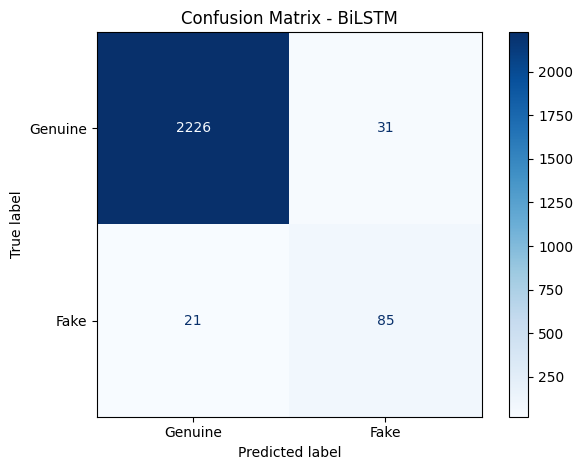

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fake"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - BiLSTM")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

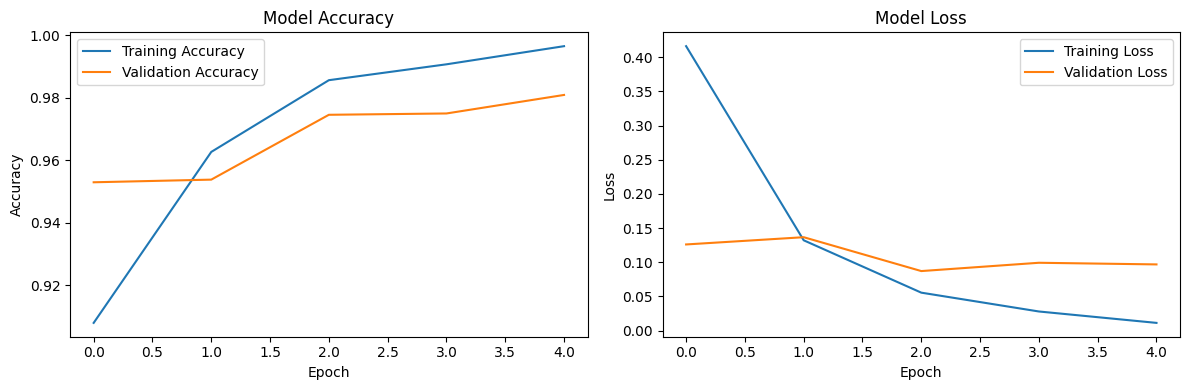

In [ ]:

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("training_graphs.png", dpi=300)
plt.show()

In [ ]:

import pandas as pd
import numpy as np

# Create a table of predictions
error_df = pd.DataFrame({
    "Actual": np.array(y_test),
    "Predicted": y_pred,
    "Fake_Probability": y_prob
})

# Identify incorrect predictions
error_df["Error_Type"] = np.where(
    error_df["Actual"] == error_df["Predicted"],
    "Correct",
    np.where(
        error_df["Actual"] == 0,
        "False Positive",
        "False Negative"
    )
)

# Show incorrect predictions
errors = error_df[error_df["Error_Type"] != "Correct"]

print("Total incorrect predictions:", len(errors))
print("\nError analysis:")
print(errors.head(10))

# Save the results
error_df.to_csv("error_analysis.csv", index=False)
print("\nSaved as error_analysis.csv")

Total incorrect predictions: 52

Error analysis:
     Actual  Predicted  Fake_Probability      Error_Type
10        0          1          0.986646  False Positive
26        0          1          0.963974  False Positive
109       0          1          0.683138  False Positive
147       0          1          0.768951  False Positive
148       0          1          0.942805  False Positive
377       0          1          0.922116  False Positive
466       1          0          0.407863  False Negative
491       1          0          0.069191  False Negative
493       1          0          0.276706  False Negative
583       0          1          0.985110  False Positive

Saved as error_analysis.csv


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Calculate the same class weights
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))

# Build BiLSTM without dropout
ablation_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, mask_zero=True),
    Bidirectional(LSTM(32)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

ablation_model.build(input_shape=(None, MAX_LEN))
ablation_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train using the same training and validation data
early_stop_ablation = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

ablation_history = ablation_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop_ablation]
)

# Evaluate on the same test data
ablation_prob = ablation_model.predict(
    X_test_pad, verbose=0
).ravel()
ablation_pred = (ablation_prob >= 0.5).astype(int)

print("\nBiLSTM without Dropout:")
print("Accuracy:", accuracy_score(y_test, ablation_pred))
print("Precision:", precision_score(y_test, ablation_pred, zero_division=0))
print("Recall:", recall_score(y_test, ablation_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, ablation_pred, zero_division=0))

# Compare both models
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "With Dropout": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ],
    "Without Dropout": [
        accuracy_score(y_test, ablation_pred),
        precision_score(y_test, ablation_pred, zero_division=0),
        recall_score(y_test, ablation_pred, zero_division=0),
        f1_score(y_test, ablation_pred, zero_division=0)
    ]
})

print("\nAblation Study Comparison:")
print(comparison.to_string(index=False))
comparison.to_csv("ablation_comparison.csv", index=False)

Epoch 1/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9160 - loss: 0.3831 - val_accuracy: 0.9543 - val_loss: 0.1229
Epoch 2/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9670 - loss: 0.1018 - val_accuracy: 0.9691 - val_loss: 0.0900
Epoch 3/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9849 - loss: 0.0447 - val_accuracy: 0.9704 - val_loss: 0.1011
Epoch 4/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9918 - loss: 0.0220 - val_accuracy: 0.9416 - val_loss: 0.2098

BiLSTM without Dropout:
Accuracy: 0.9767245027507406
Precision: 0.7107438016528925
Recall: 0.8113207547169812
F1 Score: 0.7577092511013216

Ablation Study Comparison:
   Metric  With Dropout  Without Dropout
 Accuracy      0.977994         0.976725
Precision      0.732759         0.710744
   Recall      0.801887         0.811321
 F1-score      0.765766         0.757709


In [ ]:

import os
import json
import shutil
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

# Create a folder for project results
os.makedirs("project_results", exist_ok=True)

# Save the trained BiLSTM model
model.save("project_results/fake_job_bilstm.keras")

# Save tokenizer
with open("project_results/tokenizer.json", "w") as f:
    f.write(tokenizer.to_json())

# Save test metrics
metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, zero_division=0)),
    "f1_score": float(f1_score(y_test, y_pred, zero_division=0))
}

with open("project_results/test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

# Save training history
with open("project_results/training_history.json", "w") as f:
    json.dump(
        {k: [float(v) for v in values]
         for k, values in history.history.items()},
        f, indent=4
    )

# Save ablation results
comparison.to_csv(
    "project_results/ablation_comparison.csv",
    index=False
)

# Save error analysis
error_df.to_csv(
    "project_results/error_analysis.csv",
    index=False
)

# Save graphs if they were generated
if os.path.exists("confusion_matrix.png"):
    shutil.copy("confusion_matrix.png", "project_results/")
if os.path.exists("training_graphs.png"):
    shutil.copy("training_graphs.png", "project_results/")

print("All project results saved successfully!")
print(os.listdir("project_results"))

All project results saved successfully!
['error_analysis.csv', 'confusion_matrix.png', 'ablation_comparison.csv', 'test_metrics.json', 'training_history.json', 'training_graphs.png', 'fake_job_bilstm.keras', 'tokenizer.json']


In [ ]:
import shutil
from google.colab import files

shutil.make_archive(
    "fake_job_project_results",
    "zip",
    "project_results"
)

files.download("fake_job_project_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SpatialDropout1D,
    Bidirectional, LSTM, Dense, Dropout
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# --------------------------------------------------
# Class weights
# --------------------------------------------------
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_v2 = dict(zip(classes, weights))

print("Class weights:", class_weights_v2)

# --------------------------------------------------
# Improved BiLSTM model
# --------------------------------------------------
model_v2 = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=64,
        mask_zero=True
    ),

    # Reduces overfitting in the embedding representation
    SpatialDropout1D(0.20),

    Bidirectional(
        LSTM(
            32,
            dropout=0.30
        )
    ),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.0001)
    ),

    Dropout(0.30),

    Dense(1, activation="sigmoid")
])

model_v2.build(input_shape=(None, MAX_LEN))

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# --------------------------------------------------
# Callbacks
# --------------------------------------------------
early_stop_v2 = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

reduce_lr_v2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

# --------------------------------------------------
# Train
# --------------------------------------------------
history_v2 = model_v2.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    class_weight=class_weights_v2,
    callbacks=[early_stop_v2, reduce_lr_v2],
    verbose=1
)

Class weights: {np.int64(0): np.float64(0.5235562310030395), np.int64(1): np.float64(11.112903225806452)}
Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9176 - loss: 0.5353 - val_accuracy: 0.9454 - val_loss: 0.1383 - learning_rate: 5.0000e-04
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9331 - loss: 0.1999 - val_accuracy: 0.9568 - val_loss: 0.1117 - learning_rate: 5.0000e-04
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9628 - loss: 0.1149 - val_accuracy: 0.9615 - val_loss: 0.1121 - learning_rate: 5.0000e-04
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9739 - loss: 0.0783 - val_accuracy: 0.9623 - val_loss: 0.1085 - learning_rate: 2.5000e-04
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9820 - loss: 0.0608 - val_accuracy: 0.9606 - val_loss: 0.1242 - learning_rate: 2.5000e-04
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9864 - loss: 0.0481 - val_accuracy: 0.9682

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Predict probabilities on validation data
val_prob = model_v2.predict(X_val_pad, verbose=0).ravel()

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.20, 0.81, 0.01):
    val_pred = (val_prob >= threshold).astype(int)

    score = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best validation threshold:", round(best_threshold, 2))
print("Best validation F1:", round(best_f1, 4))

Best validation threshold: 0.81
Best validation F1: 0.7822


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predict probabilities on test data
test_prob_v2 = model_v2.predict(
    X_test_pad,
    verbose=0
).ravel()

# Use threshold selected from validation data
test_pred_v2 = (
    test_prob_v2 >= best_threshold
).astype(int)

print("Improved BiLSTM Test Results")
print("-----------------------------")
print("Accuracy :", accuracy_score(y_test, test_pred_v2))
print("Precision:", precision_score(y_test, test_pred_v2, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred_v2, zero_division=0))
print("F1 Score :", f1_score(y_test, test_pred_v2, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_pred_v2,
    target_names=["Genuine", "Fake"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_v2))

Improved BiLSTM Test Results
-----------------------------
Accuracy : 0.980956411341515
Precision: 0.8588235294117647
Recall   : 0.6886792452830188
F1 Score : 0.7643979057591623

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      2257
        Fake       0.86      0.69      0.76       106

    accuracy                           0.98      2363
   macro avg       0.92      0.84      0.88      2363
weighted avg       0.98      0.98      0.98      2363


Confusion Matrix:
[[2245   12]
 [  33   73]]


In [ ]:
from sklearn.metrics import fbeta_score
import numpy as np

# Find threshold that emphasizes recall using validation data
best_threshold_recall = 0.5
best_f2 = 0

for threshold in np.arange(0.20, 0.81, 0.01):
    val_pred = (val_prob >= threshold).astype(int)

    f2 = fbeta_score(
        y_val,
        val_pred,
        beta=2,
        zero_division=0
    )

    if f2 > best_f2:
        best_f2 = f2
        best_threshold_recall = threshold

print("Recall-focused threshold:", round(best_threshold_recall, 2))
print("Validation F2-score:", round(best_f2, 4))

Recall-focused threshold: 0.74
Validation F2-score: 0.7634


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Use the recall-focused threshold selected from validation data
test_pred_recall = (
    test_prob_v2 >= best_threshold_recall
).astype(int)

print("Improved BiLSTM - Recall Focused Results")
print("-----------------------------------------")
print("Threshold:", best_threshold_recall)
print("Accuracy :", accuracy_score(y_test, test_pred_recall))
print("Precision:", precision_score(y_test, test_pred_recall, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred_recall, zero_division=0))
print("F1 Score :", f1_score(y_test, test_pred_recall, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_pred_recall,
    target_names=["Genuine", "Fake"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_recall))

Improved BiLSTM - Recall Focused Results
-----------------------------------------
Threshold: 0.7400000000000004
Accuracy : 0.9796868387642826
Precision: 0.8222222222222222
Recall   : 0.6981132075471698
F1 Score : 0.7551020408163265

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      2257
        Fake       0.82      0.70      0.76       106

    accuracy                           0.98      2363
   macro avg       0.90      0.85      0.87      2363
weighted avg       0.98      0.98      0.98      2363


Confusion Matrix:
[[2241   16]
 [  32   74]]


In [ ]:
import os

print("Model file exists:",
      os.path.exists("project_results/fake_job_bilstm.keras"))

Model file exists: True


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

# Original BiLSTM model
model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=64,
        mask_zero=True
    ),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.build(input_shape=(None, MAX_LEN))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {np.int64(0): np.float64(0.5235562310030395), np.int64(1): np.float64(11.112903225806452)}
Epoch 1/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.8508 - loss: 0.4220 - val_accuracy: 0.9543 - val_loss: 0.1323
Epoch 2/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9682 - loss: 0.1180 - val_accuracy: 0.9602 - val_loss: 0.1262
Epoch 3/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9892 - loss: 0.0439 - val_accuracy: 0.9598 - val_loss: 0.1322
Epoch 4/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9885 - loss: 0.0345 - val_accuracy: 0.9682 - val_loss: 0.1186
Epoch 5/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9966 - loss: 0.0111 - val_accuracy: 0.9793 - val_loss: 0.0920


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predict on unseen test data
final_prob = model.predict(X_test_pad, verbose=0).ravel()
final_pred = (final_prob >= 0.5).astype(int)

print("FINAL BiLSTM TEST RESULTS")
print("=========================")
print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred, zero_division=0))
print("Recall   :", recall_score(y_test, final_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, final_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_pred,
    target_names=["Genuine", "Fake"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

FINAL BiLSTM TEST RESULTS
Accuracy : 0.9805332204824376
Precision: 0.8061224489795918
Recall   : 0.7452830188679245
F1 Score : 0.7745098039215687

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      2257
        Fake       0.81      0.75      0.77       106

    accuracy                           0.98      2363
   macro avg       0.90      0.87      0.88      2363
weighted avg       0.98      0.98      0.98      2363


Confusion Matrix:
[[2238   19]
 [  27   79]]


In [ ]:
import os

os.makedirs("project_results", exist_ok=True)

model.save("project_results/fake_job_bilstm_final.keras")

print("Final verified model saved successfully!")

Final verified model saved successfully!


In [ ]:
import os

print(os.path.exists("project_results/fake_job_bilstm_final.keras"))

True


In [ ]:
with open("project_results/tokenizer.json", "w") as f:
    f.write(tokenizer.to_json())

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [ ]:
import json
import os

# Save final metrics
final_metrics = {
    "accuracy": 0.9805332204824376,
    "precision": 0.8061224489795918,
    "recall": 0.7452830188679245,
    "f1_score": 0.7745098039215687
}

with open("project_results/final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Final metrics saved successfully!")

Final metrics saved successfully!
